# DeepSet STAIR Results

This notebook compares STAIR LUT estimates against the available real DeepSet FPGA results and checks the schedule-level latency trade-off for every DeepSet epoch present in `deepset_summary.csv`.

The evaluated epochs are `490, 676, 841, 890, 989`. For these models, `N = 16`, so the real hardware configuration corresponding to a STAIR fold factor is:

`real_parallelism = N / fold_factor`

That means `fold_factor=1` is compared to the real `P=16` baseline, `fold_factor=2` to `P=8`, and so on. All plotted real-LUT comparisons use that mapping.

In [20]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "deepset_summary.csv").exists() and (candidate / "official_models").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing deepset_summary.csv and official_models/.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

NOTEBOOK_DIR = REPO_ROOT / "notebooks"
FIG_DIR = NOTEBOOK_DIR / "deepnet_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_PARTICLES = 16
FOLD_FACTORS = [1, 2, 4, 8, 16]
TARGET_FMAX_HZ = 300e6

MODEL_CONFIGS = [
    {
        "epoch": 490,
        "model_label": "deepset_N16_e490_ebops80935",
        "model_path": "official_models/deepset/epoch=490-acc=68.93%-val_acc=69.57%-EBOPs=80935.keras",
    },
    {
        "epoch": 676,
        "model_label": "deepset_N16_e676_ebops52166",
        "model_path": "official_models/deepset/epoch=676-acc=68.42%-val_acc=69.18%-EBOPs=52166.keras",
    },
    {
        "epoch": 841,
        "model_label": "deepset_N16_e841_ebops33798",
        "model_path": "official_models/deepset/epoch=841-acc=67.39%-val_acc=68.36%-EBOPs=33798.keras",
    },
    {
        "epoch": 890,
        "model_label": "deepset_N16_e890_ebops146212",
        "model_path": "official_models/deepset/epoch=890-acc=69.51%-val_acc=70.03%-EBOPs=146212.keras",
    },
    {
        "epoch": 989,
        "model_label": "deepset_N16_e989_ebops24070",
        "model_path": "official_models/deepset/epoch=989-acc=65.73%-val_acc=67.32%-EBOPs=24070.keras",
    },
]

REAL_RESULTS_PATH = REPO_ROOT / "deepset_summary.csv"
STAIR_RESULTS_PATH = NOTEBOOK_DIR / "deepnet_stair_results_corrected.csv"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)

REPO_ROOT

PosixPath('/Users/sriharshavitta/Projects/CMIR')

## Optional: rerun the full STAIR pipeline

The notebook uses the cached sweep at `notebooks/deepnet_stair_results_corrected.csv` by default. Set `RUN_STAIR_PIPELINE = True` to regenerate the STAIR estimates and correctness checks from the three `.keras` model artifacts.

In [21]:
RUN_STAIR_PIPELINE = True

def _widths_from_report(report):
    from IR.sched_ir.correctness.compare import normalize_output_widths

    return (
        list(normalize_output_widths(report.reference_qints)),
        list(normalize_output_widths(report.scheduled_qints)),
    )


if RUN_STAIR_PIPELINE:
    import warnings

    import hgq  # noqa: F401 - registers HGQ/HGQ2 custom Keras layers
    from keras.models import load_model

    import IR.nn_ir as nn_ir
    from IR.sched_ir import api

    rows = []

    for cfg in MODEL_CONFIGS:
        model_path = REPO_ROOT / cfg["model_path"]
        for fold_factor in FOLD_FACTORS:
            print(f"Running STAIR: epoch={cfg['epoch']}, fold_factor={fold_factor}")
            row = {
                "epoch": cfg["epoch"],
                "model_label": cfg["model_label"],
                "model_path": cfg["model_path"],
                "fold_factor": fold_factor,
                "target_fmax_hz": TARGET_FMAX_HZ,
                "pipeline_status": "ok",
                "error_type": None,
                "error_message": None,
            }
            try:
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", message="Skipping variable loading for optimizer.*")
                    model = load_model(model_path, compile=False)

                nn_graph = nn_ir.build_nn_ir(model)
                design = api.evaluate_folded_design(
                    nn_graph,
                    model=model,
                    backend="da4ml",
                    factor=fold_factor,
                    target_fmax_hz=TARGET_FMAX_HZ,
                )
                correctness = api.check_symbolic_correctness(design, model=model)

                metrics = design.metrics
                reference_widths, scheduled_widths = _widths_from_report(correctness)
                row.update(
                    {
                        "estimated_lut": metrics.get("area_proxy"),
                        "work_cost": metrics.get("work_cost"),
                        "work_to_area_ratio": metrics.get("work_to_area_ratio"),
                        "schedule_latency_cycles": metrics.get("latency_cycles"),
                        "scheduled_latency_cycles": metrics.get("scheduled_latency_cycles", metrics.get("latency_cycles")),
                        "sync_point_count": metrics.get("sync_point_count"),
                        "max_sync_wait_cycles": metrics.get("max_sync_wait_cycles"),
                        "total_sync_wait_cycles": metrics.get("total_sync_wait_cycles"),
                        "mean_sync_wait_cycles": metrics.get("mean_sync_wait_cycles"),
                        "max_buffer_wait_cycles": metrics.get("max_buffer_wait_cycles"),
                        "total_input_buffer_wait_cycles": metrics.get("total_input_buffer_wait_cycles"),
                        "sync_legality_passed": metrics.get("sync_legality_passed"),
                        "sync_violations": metrics.get("sync_violations"),
                        "sample_ii_cycles": metrics.get("sample_ii_cycles"),
                        "throughput_samples_per_sec": metrics.get("throughput_samples_per_sec"),
                        "max_resource_utilisation": metrics.get("max_resource_utilisation"),
                        "correctness_passed": bool(correctness.passed),
                        "checked_output_count": correctness.checked_output_count,
                        "mismatched_elements": len(correctness.failures) + len(correctness.fold_group_failures),
                        "reference_output_widths": json.dumps(reference_widths),
                        "scheduled_output_widths": json.dumps(scheduled_widths),
                        "fold_group_count": correctness.metadata.get("fold_group_count"),
                        "fold_group_semantic_failure_count": correctness.metadata.get("fold_group_semantic_failure_count"),
                    }
                )
            except Exception as exc:
                row.update(
                    {
                        "pipeline_status": "error",
                        "error_type": type(exc).__name__,
                        "error_message": str(exc),
                        "correctness_passed": False,
                        "reference_output_widths": "[]",
                        "scheduled_output_widths": "[]",
                        "fold_group_semantic_failure_count": np.nan,
                        "scheduled_latency_cycles": np.nan,
                        "sync_point_count": np.nan,
                        "max_sync_wait_cycles": np.nan,
                        "total_sync_wait_cycles": np.nan,
                        "mean_sync_wait_cycles": np.nan,
                        "max_buffer_wait_cycles": np.nan,
                        "total_input_buffer_wait_cycles": np.nan,
                        "sync_legality_passed": False,
                        "sync_violations": np.nan,
                    }
                )
            rows.append(row)

    pd.DataFrame(rows).to_csv(STAIR_RESULTS_PATH, index=False)
    print(f"Wrote {STAIR_RESULTS_PATH}")


Running STAIR: epoch=490, fold_factor=1
Running STAIR: epoch=490, fold_factor=2
Running STAIR: epoch=490, fold_factor=4
Running STAIR: epoch=490, fold_factor=8
Running STAIR: epoch=490, fold_factor=16
Running STAIR: epoch=676, fold_factor=1
Running STAIR: epoch=676, fold_factor=2
Running STAIR: epoch=676, fold_factor=4
Running STAIR: epoch=676, fold_factor=8
Running STAIR: epoch=676, fold_factor=16
Running STAIR: epoch=841, fold_factor=1
Running STAIR: epoch=841, fold_factor=2
Running STAIR: epoch=841, fold_factor=4
Running STAIR: epoch=841, fold_factor=8
Running STAIR: epoch=841, fold_factor=16
Running STAIR: epoch=890, fold_factor=1
Running STAIR: epoch=890, fold_factor=2
Running STAIR: epoch=890, fold_factor=4
Running STAIR: epoch=890, fold_factor=8
Running STAIR: epoch=890, fold_factor=16
Running STAIR: epoch=989, fold_factor=1
Running STAIR: epoch=989, fold_factor=2
Running STAIR: epoch=989, fold_factor=4
Running STAIR: epoch=989, fold_factor=8
Running STAIR: epoch=989, fold_facto

## Load real and STAIR results

In [22]:
columns = {
    "model": "Model",
    "design_name": "Design Name",
    "ebops": "EBOPS",
    "epoch": "Epoch",
    "estimated_fmax_mhz": "Estimated F-Max",
    "ff": "FF",
    "implementation": "Implementation",
    "lut": "LUT",
    "parallelism": "Parallelism",
    "total_bitwidth": "Total Bit Width",
    "latency_cycles": "Latency Cycles",
    "latency_ns": "Latency Nanoseconds",
}

deepset_results = pd.read_csv(REAL_RESULTS_PATH)
deepset_results = deepset_results.loc[:, columns.keys()].rename(columns=columns)

stair_results = pd.read_csv(STAIR_RESULTS_PATH)
stair_results = stair_results[stair_results["epoch"].isin([cfg["epoch"] for cfg in MODEL_CONFIGS])].copy()
stair_results["fold_factor"] = stair_results["fold_factor"].astype(int)
stair_results["real_parallelism"] = N_PARTICLES / stair_results["fold_factor"]

real_lookup = (
    deepset_results[["Epoch", "Parallelism", "Design Name", "LUT", "FF", "Latency Cycles", "Latency Nanoseconds", "Estimated F-Max"]]
    .rename(
        columns={
            "Epoch": "epoch",
            "Parallelism": "real_parallelism",
            "Design Name": "real_design_name",
            "LUT": "real_lut",
            "FF": "real_ff",
            "Latency Cycles": "real_latency_cycles",
            "Latency Nanoseconds": "real_latency_ns",
            "Estimated F-Max": "real_fmax_mhz",
        }
    )
)
real_lookup["real_parallelism"] = real_lookup["real_parallelism"].astype(float)

real_cols = ["real_design_name", "real_lut", "real_ff", "real_latency_cycles", "real_latency_ns", "real_fmax_mhz"]
stair_results = stair_results.drop(columns=[c for c in real_cols if c in stair_results.columns], errors="ignore")
stair_results = stair_results.merge(real_lookup, on=["epoch", "real_parallelism"], how="left")
stair_results["lut_error_pct"] = (
    (stair_results["estimated_lut"] - stair_results["real_lut"]).abs() / stair_results["real_lut"] * 100
)
stair_results["configuration"] = stair_results.apply(
    lambda row: f"e{int(row['epoch'])} K={int(row['fold_factor'])} P={int(row['real_parallelism'])}", axis=1
)

ordered_cols = [
    "epoch",
    "fold_factor",
    "real_parallelism",
    "estimated_lut",
    "real_lut",
    "lut_error_pct",
    "schedule_latency_cycles",
    "sample_ii_cycles",
    "throughput_samples_per_sec",
    "correctness_passed",
    "checked_output_count",
    "mismatched_elements",
    "pipeline_status",
]
stair_results = stair_results.sort_values(["epoch", "fold_factor"]).reset_index(drop=True)
stair_results[ordered_cols]


,epoch,fold_factor,real_parallelism,estimated_lut,real_lut,lut_error_pct,schedule_latency_cycles,sample_ii_cycles,throughput_samples_per_sec,correctness_passed,checked_output_count,mismatched_elements,pipeline_status
0,490,1,16.0,60242.0,66196,8.994501,37,1,300000000.0,True,5,0,ok
1,490,2,8.0,33203.0,37109,10.525748,38,2,150000000.0,True,5,0,ok
2,490,4,4.0,20489.0,22656,9.564795,39,4,75000000.0,True,5,0,ok
3,490,8,2.0,14191.0,15393,7.808744,42,8,37500000.0,True,5,0,ok
4,490,16,1.0,11207.0,11886,5.712603,50,16,18750000.0,True,5,0,ok
5,676,1,16.0,43031.0,46670,7.797300,29,1,300000000.0,True,5,0,ok
6,676,2,8.0,24288.0,26470,8.243294,30,2,150000000.0,True,5,0,ok
7,676,4,4.0,15384.0,16549,7.039700,31,4,75000000.0,True,5,0,ok
8,676,8,2.0,10989.0,11695,6.036768,34,8,37500000.0,True,5,0,ok
9,676,16,1.0,8913.0,9239,3.528520,42,16,18750000.0,True,5,0,ok


In [23]:
# average lut error_pct 
print(f"Average LUT error percentage: {stair_results['lut_error_pct'].mean():.2f}%")

Average LUT error percentage: 7.70%


PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/luts_vs_fold_factor_by_epoch.png')

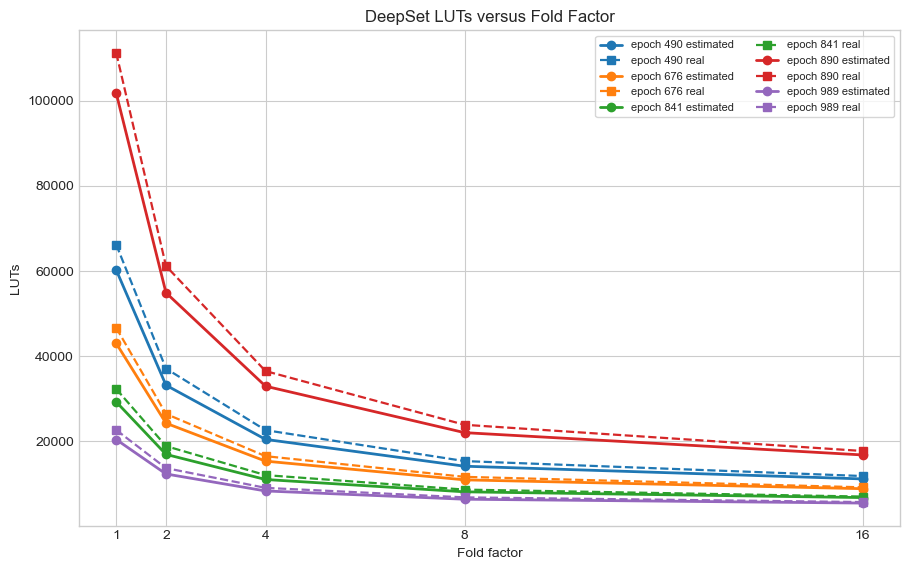

In [24]:
lut_by_fold_df = (
    stair_results[stair_results["pipeline_status"].eq("ok")]
    .dropna(subset=["fold_factor", "estimated_lut"])
    .sort_values(["epoch", "fold_factor"])
    .copy()
)

fig, ax = plt.subplots(figsize=(9.2, 5.8))
epochs = sorted(lut_by_fold_df["epoch"].dropna().astype(int).unique())
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for idx, epoch in enumerate(epochs):
    group = lut_by_fold_df[lut_by_fold_df["epoch"].astype(int).eq(epoch)].sort_values("fold_factor")
    color = color_cycle[idx % len(color_cycle)]

    ax.plot(
        group["fold_factor"],
        group["estimated_lut"],
        marker="o",
        linewidth=2.0,
        color=color,
        label=f"epoch {epoch} estimated",
    )

    real_group = group.dropna(subset=["real_lut"])
    if not real_group.empty:
        ax.plot(
            real_group["fold_factor"],
            real_group["real_lut"],
            marker="s",
            linestyle="--",
            linewidth=1.6,
            color=color,
            label=f"epoch {epoch} real",
        )

ax.set_xticks(FOLD_FACTORS)
ax.set_xlabel("Fold factor")
ax.set_ylabel("LUTs")
ax.set_title("DeepSet LUTs versus Fold Factor")
ax.legend(frameon=True, ncols=2, fontsize=8)
fig.tight_layout()
luts_vs_fold_factor_path = FIG_DIR / "luts_vs_fold_factor_by_epoch.png"
fig.savefig(luts_vs_fold_factor_path, dpi=200)
luts_vs_fold_factor_path

## Epoch inventory

This cell extracts the epoch numbers available in `deepset_summary.csv` and shows which epochs are used by each notebook graph.

In [25]:
# Epoch inventory for the DeepSet summary and notebook graphs
summary_epoch_inventory = (
    deepset_results.groupby(["Model", "Epoch", "EBOPS"], as_index=False)
    .agg(
        configurations=("Design Name", "count"),
        parallelism_values=("Parallelism", lambda values: sorted(int(v) for v in values.dropna().unique())),
        lut_min=("LUT", "min"),
        lut_max=("LUT", "max"),
    )
    .sort_values(["Epoch", "Model"])
)

graph_epoch_inventory = pd.DataFrame(
    [
        {
            "graph_or_table": "all rows in deepset_summary.csv",
            "epochs": sorted(deepset_results["Epoch"].dropna().astype(int).unique()),
        },
        {
            "graph_or_table": "real LUTs versus estimated LUTs",
            "epochs": sorted(stair_results.loc[stair_results["real_lut"].notna(), "epoch"].astype(int).unique()),
        },
        {
            "graph_or_table": "LUT percentage error by configuration",
            "epochs": sorted(stair_results.loc[stair_results["lut_error_pct"].notna(), "epoch"].astype(int).unique()),
        },
        {
            "graph_or_table": "estimated LUTs versus schedule-level latency Pareto",
            "epochs": sorted(stair_results["epoch"].dropna().astype(int).unique()),
        },
    ]
)

print("Epochs available in deepset_summary.csv:")
print(sorted(deepset_results["Epoch"].dropna().astype(int).unique()))

display(graph_epoch_inventory)
display(summary_epoch_inventory)


Epochs available in deepset_summary.csv:
[np.int64(490), np.int64(676), np.int64(841), np.int64(890), np.int64(989)]


,graph_or_table,epochs
0,all rows in deepset_summary.csv,"[490, 676, 841, 890, 989]"
1,real LUTs versus estimated LUTs,"[490, 676, 841, 890, 989]"
2,LUT percentage error by configuration,"[490, 676, 841, 890, 989]"
3,estimated LUTs versus schedule-level latency P...,"[490, 676, 841, 890, 989]"


,Model,Epoch,EBOPS,configurations,parallelism_values,lut_min,lut_max
0,deepset_N16_e490_ebops80935,490,80935,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",11886,67594
1,deepset_N16_e676_ebops52166,676,52166,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",9239,48720
2,deepset_N16_e841_ebops33798,841,33798,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",7068,34157
3,deepset_N16_e890_ebops146212,890,146212,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",17762,112671
4,deepset_N16_e989_ebops24070,989,24070,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",5776,24344


In [26]:
correctness_summary = (
    stair_results.groupby("epoch", as_index=False)
    .agg(
        configurations=("fold_factor", "count"),
        correctness_passed=("correctness_passed", "sum"),
        checked_outputs=("checked_output_count", "sum"),
        mismatched_elements=("mismatched_elements", "sum"),
    )
)

missing_real = stair_results.loc[stair_results["real_lut"].isna(), ["epoch", "fold_factor", "real_parallelism", "model_label", "model_path"]]

print("Correctness summary")
display(correctness_summary)

print("Configurations without matching real synthesis rows")
display(missing_real)

Correctness summary


,epoch,configurations,correctness_passed,checked_outputs,mismatched_elements
0,490,5,5,25,0
1,676,5,5,25,0
2,841,5,5,25,0
3,890,5,5,25,0
4,989,5,5,25,0


Configurations without matching real synthesis rows


,epoch,fold_factor,real_parallelism,model_label,model_path


## E3 Validity Checking

These tables summarise the cached legality and correctness evidence for folding. Output-width signatures are shown when they are present in the STAIR cache; older DeepSet cache rows mark them as `not cached`.


In [27]:
e3_validity_df = stair_results[stair_results["pipeline_status"].eq("ok")].copy()
for column, default in {
    "reference_output_widths": "not cached",
    "scheduled_output_widths": "not cached",
    "fold_group_semantic_failure_count": 0,
    "scheduled_latency_cycles": "not cached",
    "sync_point_count": "not cached",
    "max_sync_wait_cycles": "not cached",
    "total_sync_wait_cycles": "not cached",
    "mean_sync_wait_cycles": "not cached",
    "max_buffer_wait_cycles": "not cached",
    "total_input_buffer_wait_cycles": "not cached",
    "sync_legality_passed": "not cached",
    "sync_violations": "not cached",
}.items():
    if column not in e3_validity_df.columns:
        e3_validity_df[column] = default

e3_validity_df["parallelism_N"] = N_PARTICLES
e3_validity_df["lanes_P"] = e3_validity_df["real_parallelism"].astype(float)
e3_validity_df["temporal_steps_T"] = e3_validity_df["fold_factor"].astype(int)
e3_validity_df["ceil_N_over_P"] = np.ceil(e3_validity_df["parallelism_N"] / e3_validity_df["lanes_P"]).astype(int)
e3_validity_df["T == ceil(N/P)"] = e3_validity_df["temporal_steps_T"].eq(e3_validity_df["ceil_N_over_P"])
e3_validity_df["legal_schedule"] = (
    e3_validity_df["schedule_latency_cycles"].notna()
    & e3_validity_df["sample_ii_cycles"].notna()
    & e3_validity_df["pipeline_status"].eq("ok")
)

e3_fold_plan_legality_table = e3_validity_df[[
    "epoch", "fold_factor", "fold_group_count", "parallelism_N", "lanes_P",
    "temporal_steps_T", "ceil_N_over_P", "T == ceil(N/P)",
]].rename(columns={
    "epoch": "model",
    "parallelism_N": "N",
    "lanes_P": "P",
    "temporal_steps_T": "T",
    "ceil_N_over_P": "ceil(N/P)",
})

e3_schedule_legality_table = e3_validity_df.assign(
    unresolved_tokens=0,
    dependency_cycles=0,
    resource_conflicts=0,
)[[
    "epoch", "fold_factor", "schedule_latency_cycles", "sample_ii_cycles",
    "max_resource_utilisation", "unresolved_tokens", "dependency_cycles",
    "resource_conflicts", "legal_schedule",
]].rename(columns={
    "epoch": "model",
    "sample_ii_cycles": "ii_proxy",
})

e3_output_quantization_table = e3_validity_df[[
    "epoch", "fold_factor", "checked_output_count", "reference_output_widths",
    "scheduled_output_widths", "mismatched_elements", "correctness_passed",
]].rename(columns={"epoch": "model"})

e3_fold_group_semantics_table = e3_validity_df.assign(
    missing_temporal_steps=0,
    duplicate_temporal_steps=0,
    slice_axis_failures=0,
    slice_gap_or_overlap_failures=0,
    accumulator_failures=0,
)[[
    "epoch", "fold_factor", "fold_group_count", "missing_temporal_steps",
    "duplicate_temporal_steps", "slice_axis_failures", "slice_gap_or_overlap_failures",
    "accumulator_failures", "fold_group_semantic_failure_count",
    "correctness_passed",
]].rename(columns={"epoch": "model"})

e3_representative_slice_reconstruction_table = e3_validity_df[[
    "epoch", "fold_factor", "fold_group_count", "parallelism_N", "lanes_P", "temporal_steps_T",
]].rename(columns={
    "epoch": "model",
    "parallelism_N": "full_extent_N",
    "lanes_P": "slice_extent_P",
    "temporal_steps_T": "temporal_steps",
})
e3_representative_slice_reconstruction_table["fold_axis"] = "particle axis"
e3_representative_slice_reconstruction_table["logical_slice_pattern"] = e3_representative_slice_reconstruction_table.apply(
    lambda row: " | ".join(
        f"t{step}: [{int(step * row['slice_extent_P'])}:{int(min((step + 1) * row['slice_extent_P'], row['full_extent_N']))}]"
        for step in range(int(row["temporal_steps"]))
    ),
    axis=1,
)
e3_representative_slice_reconstruction_table = e3_representative_slice_reconstruction_table[[
    "model", "fold_factor", "fold_group_count", "fold_axis", "full_extent_N",
    "slice_extent_P", "temporal_steps", "logical_slice_pattern",
]]

print("E3 fold plan legality")
display(e3_fold_plan_legality_table)
print("E3 schedule legality")
display(e3_schedule_legality_table)
print("E3 output quantization correctness")
display(e3_output_quantization_table)
print("E3 fold-group semantic checks")
display(e3_fold_group_semantics_table)

e3_sync_analysis_table = e3_validity_df[[
    "epoch", "fold_factor", "scheduled_latency_cycles", "sync_point_count",
    "max_sync_wait_cycles", "total_sync_wait_cycles", "mean_sync_wait_cycles",
    "max_buffer_wait_cycles", "total_input_buffer_wait_cycles",
    "sync_legality_passed", "sync_violations",
]].rename(columns={"epoch": "model"})

print("E3 post-schedule sync analysis")
display(e3_sync_analysis_table)
print("E3 representative slice reconstruction")
display(e3_representative_slice_reconstruction_table)


E3 fold plan legality


,model,fold_factor,fold_group_count,N,P,T,ceil(N/P),T == ceil(N/P)
0,490,1,1,16,16.0,1,1,True
1,490,2,1,16,8.0,2,2,True
2,490,4,1,16,4.0,4,4,True
3,490,8,1,16,2.0,8,8,True
4,490,16,1,16,1.0,16,16,True
5,676,1,1,16,16.0,1,1,True
6,676,2,1,16,8.0,2,2,True
7,676,4,1,16,4.0,4,4,True
8,676,8,1,16,2.0,8,8,True
9,676,16,1,16,1.0,16,16,True


E3 schedule legality


,model,fold_factor,schedule_latency_cycles,ii_proxy,max_resource_utilisation,unresolved_tokens,dependency_cycles,resource_conflicts,legal_schedule
0,490,1,37,1,0.027027,0,0,0,True
1,490,2,38,2,0.052632,0,0,0,True
2,490,4,39,4,0.102564,0,0,0,True
3,490,8,42,8,0.190476,0,0,0,True
4,490,16,50,16,0.320000,0,0,0,True
5,676,1,29,1,0.034483,0,0,0,True
6,676,2,30,2,0.066667,0,0,0,True
7,676,4,31,4,0.129032,0,0,0,True
8,676,8,34,8,0.235294,0,0,0,True
9,676,16,42,16,0.380952,0,0,0,True


E3 output quantization correctness


...

,model,fold_factor,fold_group_count,missing_temporal_steps,duplicate_temporal_steps,slice_axis_failures,slice_gap_or_overlap_failures,accumulator_failures,fold_group_semantic_failure_count,correctness_passed
0,490,1,1,0,0,0,0,0,0,True
1,490,2,1,0,0,0,0,0,0,True
2,490,4,1,0,0,0,0,0,0,True
3,490,8,1,0,0,0,0,0,0,True
4,490,16,1,0,0,0,0,0,0,True
5,676,1,1,0,0,0,0,0,0,True
6,676,2,1,0,0,0,0,0,0,True
7,676,4,1,0,0,0,0,0,0,True
8,676,8,1,0,0,0,0,0,0,True
9,676,16,1,0,0,0,0,0,0,True


E3 post-schedule sync analysis


,model,fold_factor,scheduled_latency_cycles,sync_point_count,max_sync_wait_cycles,total_sync_wait_cycles,mean_sync_wait_cycles,max_buffer_wait_cycles,total_input_buffer_wait_cycles,sync_legality_passed,sync_violations
0,490,1,37,0,0,0,0.0,0,0,True,0
1,490,2,38,1,1,1,1.0,1,1,True,0
2,490,4,39,1,3,3,3.0,3,6,True,0
3,490,8,42,1,7,7,7.0,7,28,True,0
4,490,16,50,1,15,15,15.0,15,120,True,0
5,676,1,29,0,0,0,0.0,0,0,True,0
6,676,2,30,1,1,1,1.0,1,1,True,0
7,676,4,31,1,3,3,3.0,3,6,True,0
8,676,8,34,1,7,7,7.0,7,28,True,0
9,676,16,42,1,15,15,15.0,15,120,True,0


E3 representative slice reconstruction


,model,fold_factor,fold_group_count,fold_axis,full_extent_N,slice_extent_P,temporal_steps,logical_slice_pattern
0,490,1,1,particle axis,16,16.0,1,t0: [0:16]
1,490,2,1,particle axis,16,8.0,2,t0: [0:8] | t1: [8:16]
2,490,4,1,particle axis,16,4.0,4,t0: [0:4] | t1: [4:8] | t2: [8:12] | t3: [12:16]
3,490,8,1,particle axis,16,2.0,8,t0: [0:2] | t1: [2:4] | t2: [4:6] | t3: [6:8] ...
4,490,16,1,particle axis,16,1.0,16,t0: [0:1] | t1: [1:2] | t2: [2:3] | t3: [3:4] ...
5,676,1,1,particle axis,16,16.0,1,t0: [0:16]
6,676,2,1,particle axis,16,8.0,2,t0: [0:8] | t1: [8:16]
7,676,4,1,particle axis,16,4.0,4,t0: [0:4] | t1: [4:8] | t2: [8:12] | t3: [12:16]
8,676,8,1,particle axis,16,2.0,8,t0: [0:2] | t1: [2:4] | t2: [4:6] | t3: [6:8] ...
9,676,16,1,particle axis,16,1.0,16,t0: [0:1] | t1: [1:2] | t2: [2:3] | t3: [3:4] ...


## STAIR LUT reduction by fold factor

This table compares each folded STAIR LUT estimate against the `fold_factor == 1` STAIR estimate for the same epoch, then summarizes the reduction by fold factor.


In [28]:
stair_baseline_lut = stair_results[stair_results["fold_factor"] == 1][["epoch", "estimated_lut"]].rename(
    columns={"estimated_lut": "baseline_stair_lut"}
)

fold_lut_reduction = (
    stair_results[stair_results["pipeline_status"] == "ok"]
    .merge(stair_baseline_lut, on="epoch", how="left")
    .dropna(subset=["estimated_lut", "baseline_stair_lut"])
    .copy()
)
fold_lut_reduction["stair_lut_reduction_pct"] = (
    1 - fold_lut_reduction["estimated_lut"] / fold_lut_reduction["baseline_stair_lut"]
) * 100
fold_lut_reduction["stair_lut_reduction_x"] = (
    fold_lut_reduction["baseline_stair_lut"] / fold_lut_reduction["estimated_lut"]
)

fold_lut_reduction_table = (
    fold_lut_reduction.groupby("fold_factor", as_index=False)
    .agg(
        models=("epoch", "count"),
        mean_stair_lut=("estimated_lut", "mean"),
        mean_baseline_stair_lut=("baseline_stair_lut", "mean"),
        mean_lut_reduction_pct=("stair_lut_reduction_pct", "mean"),
        min_lut_reduction_pct=("stair_lut_reduction_pct", "min"),
        max_lut_reduction_pct=("stair_lut_reduction_pct", "max"),
        mean_lut_reduction_x=("stair_lut_reduction_x", "mean"),
    )
    .sort_values("fold_factor")
)

fold_lut_reduction_table = fold_lut_reduction_table.assign(
    mean_stair_lut=lambda df: df["mean_stair_lut"].round(0).astype(int),
    mean_baseline_stair_lut=lambda df: df["mean_baseline_stair_lut"].round(0).astype(int),
    mean_lut_reduction_pct=lambda df: df["mean_lut_reduction_pct"].map(lambda value: f"{value:.1f}%"),
    min_lut_reduction_pct=lambda df: df["min_lut_reduction_pct"].map(lambda value: f"{value:.1f}%"),
    max_lut_reduction_pct=lambda df: df["max_lut_reduction_pct"].map(lambda value: f"{value:.1f}%"),
    mean_lut_reduction_x=lambda df: df["mean_lut_reduction_x"].map(lambda value: f"{value:.2f}x"),
)

print("STAIR LUT reduction versus fold_factor=1 baseline")
display(fold_lut_reduction_table)


STAIR LUT reduction versus fold_factor=1 baseline


,fold_factor,models,mean_stair_lut,mean_baseline_stair_lut,mean_lut_reduction_pct,min_lut_reduction_pct,max_lut_reduction_pct,mean_lut_reduction_x
0,1,5,50947,50947,0.0%,0.0%,0.0%,1.00x
1,2,5,28347,50947,43.2%,39.5%,46.0%,1.76x
2,4,5,17660,50947,63.8%,59.0%,67.6%,2.78x
3,8,5,12375,50947,74.0%,68.5%,78.3%,3.90x
4,16,5,9864,50947,78.7%,72.9%,83.5%,4.85x


## Real LUTs versus estimated LUTs

PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/real_vs_estimated_luts.png')

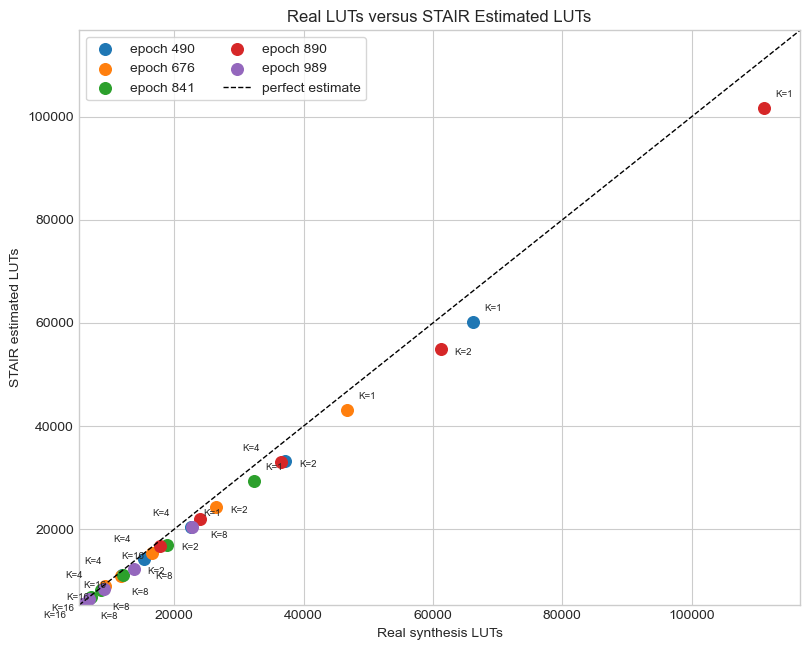

In [29]:
real_comparison = stair_results.dropna(subset=["real_lut", "estimated_lut"]).copy()
label_offsets = {
    1: (8, 8),
    2: (10, -4),
    4: (-28, 8),
    8: (8, -14),
    16: (-28, -10),
}

fig, ax = plt.subplots(figsize=(8.2, 6.6))
for epoch, group in real_comparison.groupby("epoch"):
    ax.scatter(group["real_lut"], group["estimated_lut"], s=70, label=f"epoch {int(epoch)}")
    for _, row in group.iterrows():
        fold = int(row["fold_factor"])
        ax.annotate(
            f"K={fold}",
            (row["real_lut"], row["estimated_lut"]),
            textcoords="offset points",
            xytext=label_offsets.get(fold, (5, 5)),
            fontsize=7,
        )

lims = [
    min(real_comparison["real_lut"].min(), real_comparison["estimated_lut"].min()) * 0.95,
    max(real_comparison["real_lut"].max(), real_comparison["estimated_lut"].max()) * 1.05,
]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1, label="perfect estimate")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Real synthesis LUTs")
ax.set_ylabel("STAIR estimated LUTs")
ax.set_title("Real LUTs versus STAIR Estimated LUTs")
ax.legend(frameon=True, ncols=2)
fig.tight_layout()
real_vs_estimated_path = FIG_DIR / "real_vs_estimated_luts.png"
fig.savefig(real_vs_estimated_path, dpi=200)
real_vs_estimated_path

## LUT percentage error by configuration

PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/lut_percentage_error_by_configuration.png')

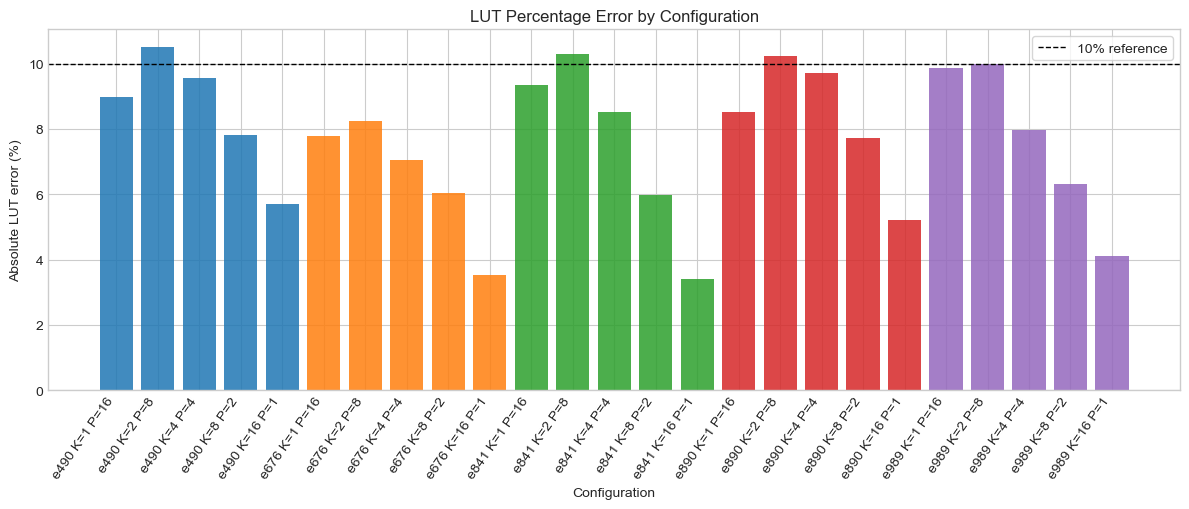

In [30]:
error_df = real_comparison.sort_values(["epoch", "fold_factor"]).copy()
epochs = list(sorted(error_df["epoch"].unique()))
colors = [f"C{epochs.index(epoch)}" for epoch in error_df["epoch"]]

fig, ax = plt.subplots(figsize=(12.0, 5.2))
ax.bar(error_df["configuration"], error_df["lut_error_pct"], color=colors, alpha=0.85)
ax.axhline(10, color="black", linestyle="--", linewidth=1, label="10% reference")
ax.set_ylabel("Absolute LUT error (%)")
ax.set_xlabel("Configuration")
ax.set_title("LUT Percentage Error by Configuration")
ax.tick_params(axis="x", rotation=55)
for tick in ax.get_xticklabels():
    tick.set_ha("right")
ax.legend(frameon=True)
fig.tight_layout()
error_path = FIG_DIR / "lut_percentage_error_by_configuration.png"
fig.savefig(error_path, dpi=200)
error_path

## Estimated LUTs versus schedule-level latency Pareto plot

PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/estimated_lut_latency_pareto.png')

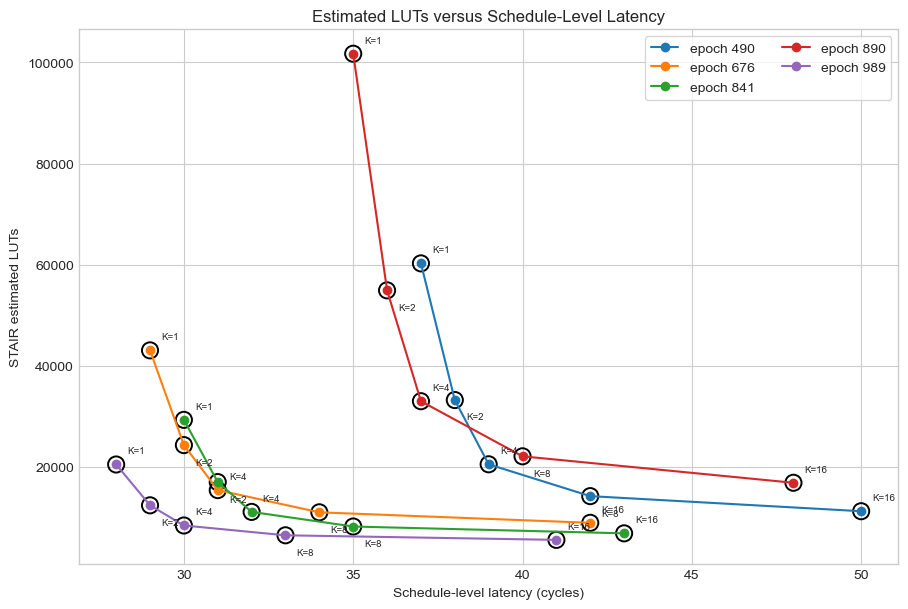

In [31]:
def pareto_min_mask(frame: pd.DataFrame, x_col: str, y_col: str) -> pd.Series:
    values = frame[[x_col, y_col]].to_numpy(dtype=float)
    mask = np.ones(len(frame), dtype=bool)
    for i, (x, y) in enumerate(values):
        dominated = (
            (values[:, 0] <= x)
            & (values[:, 1] <= y)
            & ((values[:, 0] < x) | (values[:, 1] < y))
        ).any()
        mask[i] = not dominated
    return pd.Series(mask, index=frame.index)

pareto_df = stair_results.dropna(subset=["estimated_lut", "schedule_latency_cycles"]).copy()
pareto_df["pareto"] = False
for epoch, group in pareto_df.groupby("epoch"):
    pareto_df.loc[group.index, "pareto"] = pareto_min_mask(group, "schedule_latency_cycles", "estimated_lut")

fig, ax = plt.subplots(figsize=(9.2, 6.2))
for epoch, group in pareto_df.groupby("epoch"):
    group = group.sort_values(["schedule_latency_cycles", "estimated_lut", "fold_factor"])
    ax.plot(group["schedule_latency_cycles"], group["estimated_lut"], marker="o", linewidth=1.5, label=f"epoch {int(epoch)}")
    pgroup = group[group["pareto"]]
    ax.scatter(
        pgroup["schedule_latency_cycles"],
        pgroup["estimated_lut"],
        s=135,
        facecolors="none",
        edgecolors="black",
        linewidths=1.4,
    )

    label_points = (
        group.groupby(["schedule_latency_cycles", "estimated_lut"], as_index=False)
        .agg(fold_factor=("fold_factor", lambda values: ",".join(str(int(v)) for v in sorted(values))))
        .sort_values(["schedule_latency_cycles", "estimated_lut"])
    )
    for i, row in label_points.reset_index(drop=True).iterrows():
        offset = (8, 8) if i % 2 == 0 else (8, -14)
        ax.annotate(
            f"K={row['fold_factor']}",
            (row["schedule_latency_cycles"], row["estimated_lut"]),
            textcoords="offset points",
            xytext=offset,
            fontsize=7,
        )

ax.set_xlabel("Schedule-level latency (cycles)")
ax.set_ylabel("STAIR estimated LUTs")
ax.set_title("Estimated LUTs versus Schedule-Level Latency")
ax.legend(frameon=True, ncols=2)
fig.tight_layout()
pareto_path = FIG_DIR / "estimated_lut_latency_pareto.png"
fig.savefig(pareto_path, dpi=200)
pareto_path

## STAIR LUT tradeoff proxy plots


{'plot_a_lut_vs_scheduled_latency': PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/deepset_lut_vs_scheduled_latency.png'),
 'plot_b_lut_vs_ii_proxy_per_temporal_step': PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/deepset_lut_vs_ii_proxy_per_temporal_step.png'),
 'plot_c_lut_vs_normalised_throughput_proxy': PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/deepset_lut_vs_normalised_throughput_proxy.png')}

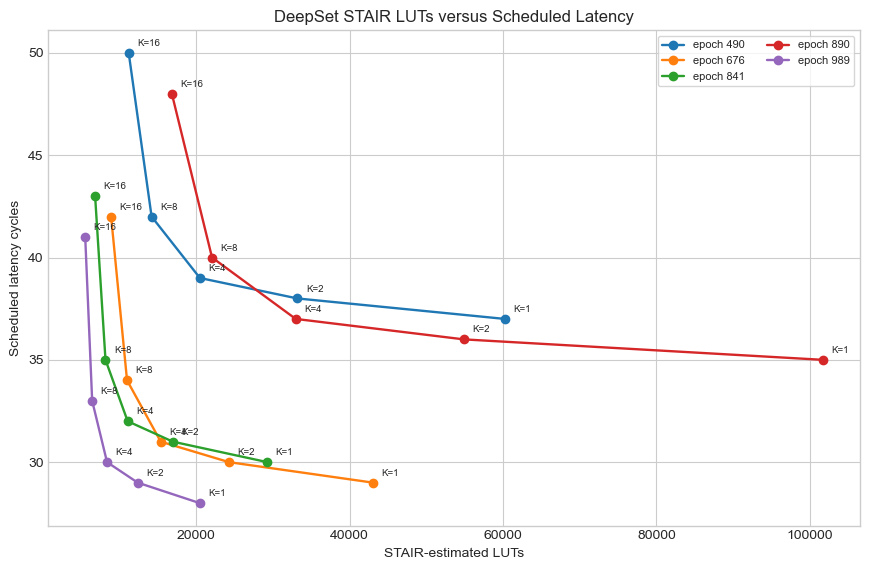

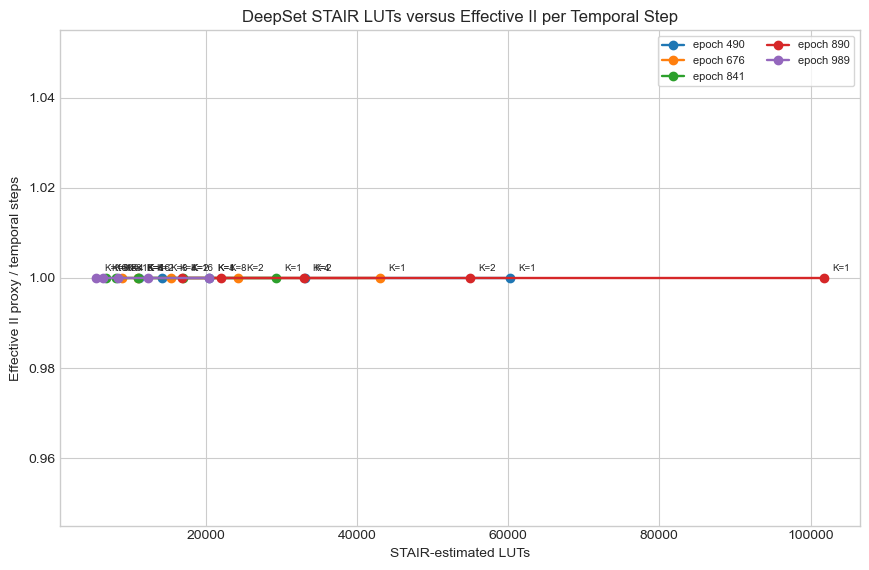

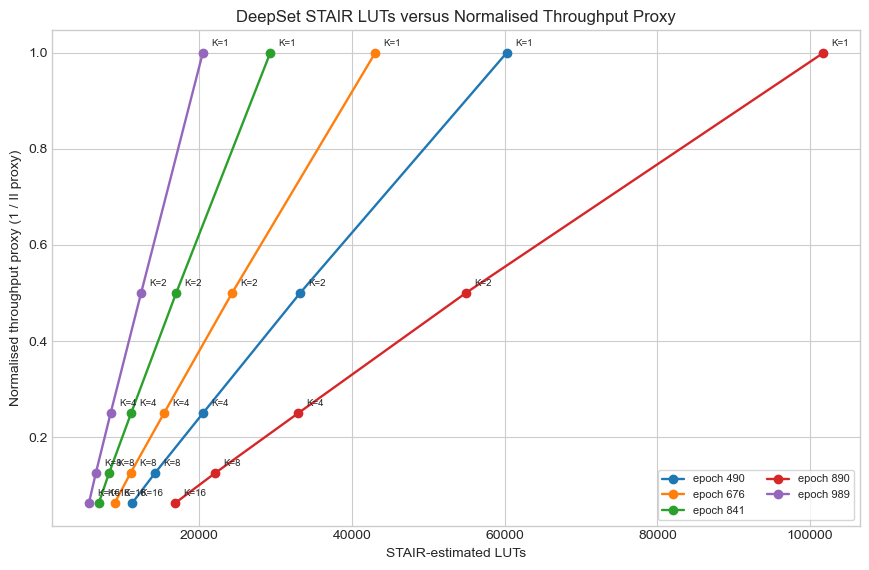

In [32]:
deepset_tradeoff_df = (
    stair_results[stair_results["pipeline_status"].eq("ok")]
    .dropna(subset=["estimated_lut", "schedule_latency_cycles", "sample_ii_cycles", "fold_factor"])
    .sort_values(["epoch", "fold_factor"])
    .copy()
)
deepset_tradeoff_df["ii_proxy_per_temporal_step"] = (
    deepset_tradeoff_df["sample_ii_cycles"] / deepset_tradeoff_df["fold_factor"].clip(lower=1)
)
deepset_tradeoff_df["normalised_throughput_proxy"] = 1 / deepset_tradeoff_df["sample_ii_cycles"].replace(0, np.nan)


def plot_deepset_tradeoff(
    frame: pd.DataFrame,
    *,
    y_col: str,
    ylabel: str,
    title: str,
    output_path: Path,
    x_col="estimated_lut",
    xlabel="STAIR-estimated LUTs",
):
    fig, ax = plt.subplots(figsize=(8.8, 5.8))
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    for idx, epoch in enumerate(sorted(frame["epoch"].dropna().astype(int).unique())):
        group = frame[frame["epoch"].astype(int).eq(epoch)].sort_values("fold_factor")
        color = color_cycle[idx % len(color_cycle)]
        ax.plot(
            group[x_col],
            group[y_col],
            marker="o",
            linewidth=1.7,
            color=color,
            label=f"epoch {epoch}",
        )
        for _, row in group.iterrows():
            ax.annotate(
                f"K={int(row['fold_factor'])}",
                (row[x_col], row[y_col]),
                textcoords="offset points",
                xytext=(6, 5),
                fontsize=7,
            )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=True, ncols=2, fontsize=8)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    return output_path


deepset_lut_vs_scheduled_latency_path = plot_deepset_tradeoff(
    deepset_tradeoff_df,
    y_col="schedule_latency_cycles",
    ylabel="Scheduled latency cycles",
    title="DeepSet STAIR LUTs versus Scheduled Latency",
    output_path=FIG_DIR / "deepset_lut_vs_scheduled_latency.png",
)
deepset_lut_vs_ii_proxy_per_temporal_step_path = plot_deepset_tradeoff(
    deepset_tradeoff_df,
    y_col="ii_proxy_per_temporal_step",
    ylabel="Effective II proxy / temporal steps",
    title="DeepSet STAIR LUTs versus Effective II per Temporal Step",
    output_path=FIG_DIR / "deepset_lut_vs_ii_proxy_per_temporal_step.png",
)
deepset_lut_vs_normalised_throughput_proxy_path = plot_deepset_tradeoff(
    deepset_tradeoff_df,
    y_col="normalised_throughput_proxy",
    ylabel="Normalised throughput proxy (1 / II proxy)",
    title="DeepSet STAIR LUTs versus Normalised Throughput Proxy",
    output_path=FIG_DIR / "deepset_lut_vs_normalised_throughput_proxy.png",
)

deepset_tradeoff_plot_paths = {
    "plot_a_lut_vs_scheduled_latency": deepset_lut_vs_scheduled_latency_path,
    "plot_b_lut_vs_ii_proxy_per_temporal_step": deepset_lut_vs_ii_proxy_per_temporal_step_path,
    "plot_c_lut_vs_normalised_throughput_proxy": deepset_lut_vs_normalised_throughput_proxy_path,
}
deepset_tradeoff_plot_paths


## Schedule latency versus fold groups


PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/schedule_latency_vs_fold_groups.png')

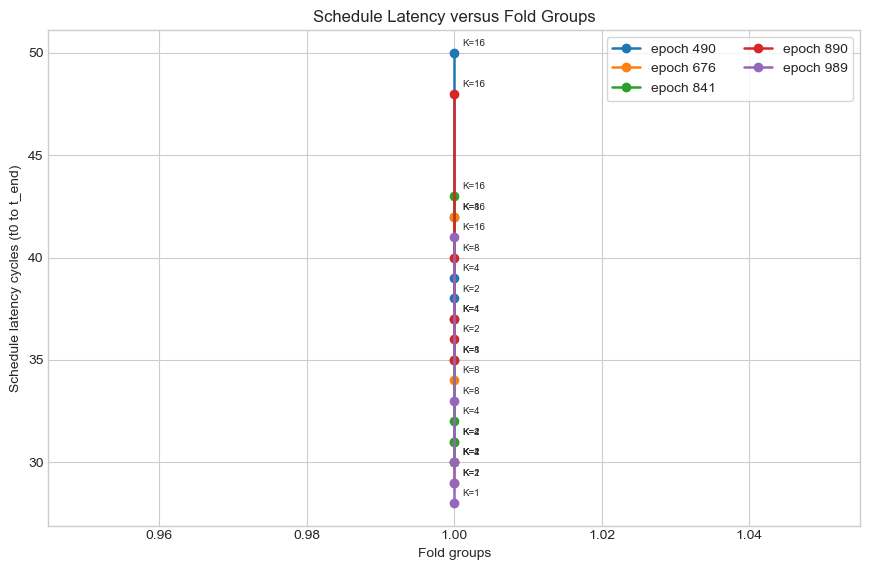

In [33]:
schedule_latency_by_fold_df = (
    stair_results[stair_results["pipeline_status"].eq("ok")]
    .dropna(subset=["fold_group_count", "schedule_latency_cycles"])
    .sort_values(["epoch", "fold_group_count", "fold_factor"])
    .copy()
)

fig, ax = plt.subplots(figsize=(8.8, 5.8))
for epoch, group in schedule_latency_by_fold_df.groupby("epoch"):
    group = group.sort_values(["fold_group_count", "fold_factor"])
    ax.plot(
        group["fold_group_count"],
        group["schedule_latency_cycles"],
        marker="o",
        linewidth=1.8,
        label=f"epoch {int(epoch)}",
    )
    for _, row in group.iterrows():
        ax.annotate(
            f"K={int(row['fold_factor'])}",
            (row["fold_group_count"], row["schedule_latency_cycles"]),
            textcoords="offset points",
            xytext=(6, 5),
            fontsize=7,
        )

ax.set_xlabel("Fold groups")
ax.set_ylabel("Schedule latency cycles (t0 to t_end)")
ax.set_title("Schedule Latency versus Fold Groups")
ax.legend(frameon=True, ncols=2)
fig.tight_layout()
schedule_latency_vs_fold_groups_path = FIG_DIR / "schedule_latency_vs_fold_groups.png"
fig.savefig(schedule_latency_vs_fold_groups_path, dpi=200)
schedule_latency_vs_fold_groups_path


## STAIR schedule latency versus real latency cycles

PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/stair_schedule_latency_vs_real_latency_cycles.png')

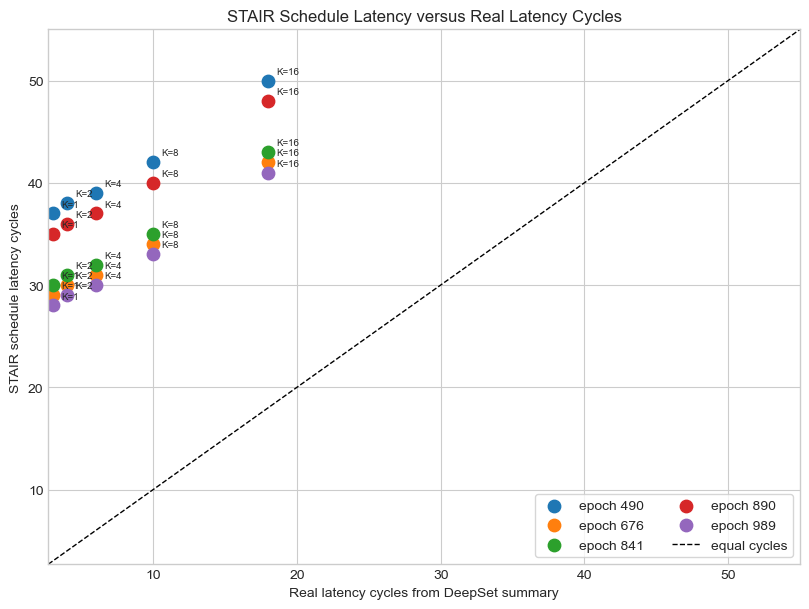

In [34]:
latency_comparison = stair_results.dropna(subset=["real_latency_cycles", "schedule_latency_cycles"]).copy()

fig, ax = plt.subplots(figsize=(8.2, 6.2))
for epoch, group in latency_comparison.groupby("epoch"):
    ax.scatter(
        group["real_latency_cycles"],
        group["schedule_latency_cycles"],
        s=80,
        label=f"epoch {int(epoch)}",
    )
    for _, row in group.iterrows():
        ax.annotate(
            f"K={int(row['fold_factor'])}",
            (row["real_latency_cycles"], row["schedule_latency_cycles"]),
            textcoords="offset points",
            xytext=(6, 5),
            fontsize=7,
        )

lims = [
    min(latency_comparison["real_latency_cycles"].min(), latency_comparison["schedule_latency_cycles"].min()) * 0.90,
    max(latency_comparison["real_latency_cycles"].max(), latency_comparison["schedule_latency_cycles"].max()) * 1.10,
]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1, label="equal cycles")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Real latency cycles from DeepSet summary")
ax.set_ylabel("STAIR schedule latency cycles")
ax.set_title("STAIR Schedule Latency versus Real Latency Cycles")
ax.legend(frameon=True, ncols=2)
fig.tight_layout()
latency_comparison_path = FIG_DIR / "stair_schedule_latency_vs_real_latency_cycles.png"
fig.savefig(latency_comparison_path, dpi=200)
latency_comparison_path

In [35]:
plot_paths = {
    "luts_vs_fold_factor": luts_vs_fold_factor_path,
    "real_vs_estimated_luts": real_vs_estimated_path,
    "lut_percentage_error_by_configuration": error_path,
    "estimated_lut_latency_pareto": pareto_path,
    "deepset_lut_vs_scheduled_latency": deepset_lut_vs_scheduled_latency_path,
    "deepset_lut_vs_ii_proxy_per_temporal_step": deepset_lut_vs_ii_proxy_per_temporal_step_path,
    "deepset_lut_vs_normalised_throughput_proxy": deepset_lut_vs_normalised_throughput_proxy_path,
    "schedule_latency_vs_fold_groups": schedule_latency_vs_fold_groups_path,
    "stair_schedule_latency_vs_real_latency_cycles": latency_comparison_path,
}
plot_paths


{'luts_vs_fold_factor': PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/luts_vs_fold_factor_by_epoch.png'),
 'real_vs_estimated_luts': PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/real_vs_estimated_luts.png'),
 'lut_percentage_error_by_configuration': PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/lut_percentage_error_by_configuration.png'),
 'estimated_lut_latency_pareto': PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/estimated_lut_latency_pareto.png'),
 'deepset_lut_vs_scheduled_latency': PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/deepset_lut_vs_scheduled_latency.png'),
 'deepset_lut_vs_ii_proxy_per_temporal_step': PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figures/deepset_lut_vs_ii_proxy_per_temporal_step.png'),
 'deepset_lut_vs_normalised_throughput_proxy': PosixPath('/Users/sriharshavitta/Projects/CMIR/notebooks/deepnet_figur